In [47]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [30]:
data = fetch_20newsgroups(subset='all')

In [31]:
df = pd.DataFrame(data.data)

In [32]:
df

,0
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...
4,From: Alexander Samuel McDiarmid <am2o+@andrew...
...,...
18841,From: jim.zisfein@factory.com (Jim Zisfein) \n...
18842,From: rdell@cbnewsf.cb.att.com (richard.b.dell...
18843,From: westes@netcom.com (Will Estes)\nSubject:...
18844,From: steve@hcrlgw (Steven Collins)\nSubject: ...


In [33]:
df = pd.DataFrame({
    'text': data.data,
    'label': data.target,
    'category':[data.target_names[i] for i in data.target]
})

In [34]:
df

,text,label,category
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware
...,...,...,...
18841,From: jim.zisfein@factory.com (Jim Zisfein) \n...,13,sci.med
18842,From: rdell@cbnewsf.cb.att.com (richard.b.dell...,12,sci.electronics
18843,From: westes@netcom.com (Will Estes)\nSubject:...,3,comp.sys.ibm.pc.hardware
18844,From: steve@hcrlgw (Steven Collins)\nSubject: ...,1,comp.graphics


In [35]:
df['category'].value_counts()

category
rec.sport.hockey            999
soc.religion.christian      997
rec.motorcycles             996
rec.sport.baseball          994
sci.crypt                   991
rec.autos                   990
sci.med                     990
comp.windows.x              988
sci.space                   987
comp.os.ms-windows.misc     985
sci.electronics             984
comp.sys.ibm.pc.hardware    982
misc.forsale                975
comp.graphics               973
comp.sys.mac.hardware       963
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64

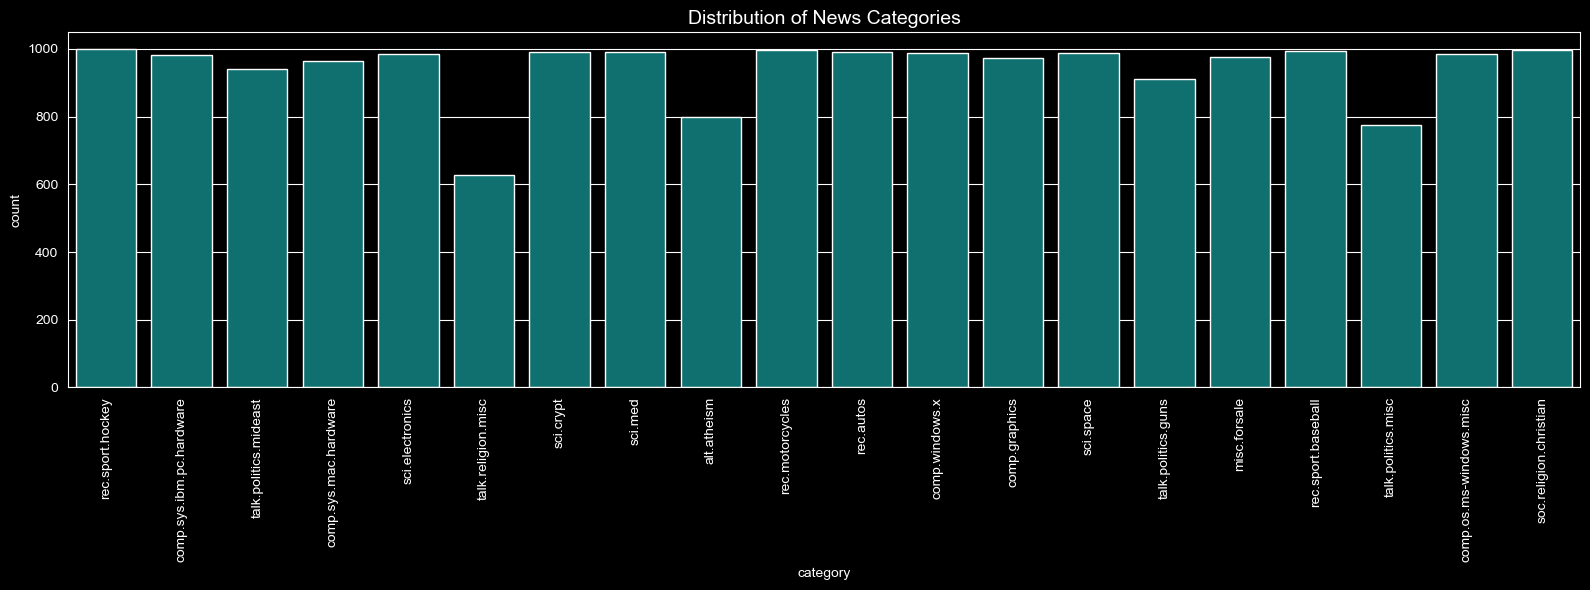

In [36]:
plt.figure(figsize=(16, 6))
sns.countplot(x='category', data=df, color='teal')
plt.title("Distribution of News Categories", fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [37]:
def clean_text(text):
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    return text

In [38]:
df["cleaned_text"] = df["text"].apply(lambda x: clean_text(x))

In [39]:
df

,text,label,category,cleaned_text
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey,from mamatha devineni ratnam subject pens fans...
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware,from matthew b lawson subject which highperfor...
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast,from hilmi eren subject re armenia says it cou...
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware,from guy dawson subject re ide vs scsi dma and...
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware,from alexander samuel mcdiarmid subject driver...
...,...,...,...,...
18841,From: jim.zisfein@factory.com (Jim Zisfein) \n...,13,sci.med,from jim zisfein subject re migraines and scan...
18842,From: rdell@cbnewsf.cb.att.com (richard.b.dell...,12,sci.electronics,from richardbdell subject re a question about ...
18843,From: westes@netcom.com (Will Estes)\nSubject:...,3,comp.sys.ibm.pc.hardware,from will estes subject mounting cpu cooler in...
18844,From: steve@hcrlgw (Steven Collins)\nSubject: ...,1,comp.graphics,from steven collins subject re sphere from poi...


In [40]:
df.drop(columns=['text'], inplace=True)

In [41]:
X = df['cleaned_text']
y = df['label']

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [43]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=5,
    max_df=0.95
)

In [44]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [45]:
batch_size = 500
indices = np.arange(X_train_tfidf.shape[0])
np.random.shuffle(indices)

y_train_np = y_train.to_numpy()

X_train_batches = [X_train_tfidf[indices[i:i+batch_size]]
                   for i in range(0, len(indices), batch_size)]
y_train_batches = [y_train_np[indices[i:i+batch_size]]
                   for i in range(0, len(indices), batch_size)]


In [46]:
sgd = SGDClassifier(loss='log_loss', max_iter=1, learning_rate='optimal')
batch_accuracies = []

for i, (Xb, yb) in enumerate(zip(X_train_batches, y_train_batches)):
    sgd.partial_fit(Xb, yb, classes=np.unique(y_train_np))
    acc = accuracy_score(y_test, sgd.predict(X_test_tfidf))
    batch_accuracies.append(acc)
    print(f"After batch {i+1}, accuracy={acc:.4f}")

After batch 1, accuracy=0.6167
After batch 2, accuracy=0.7271
After batch 3, accuracy=0.7597
After batch 4, accuracy=0.7878
After batch 5, accuracy=0.8008
After batch 6, accuracy=0.8151
After batch 7, accuracy=0.8199
After batch 8, accuracy=0.8231
After batch 9, accuracy=0.8358
After batch 10, accuracy=0.8406
After batch 11, accuracy=0.8451
After batch 12, accuracy=0.8512
After batch 13, accuracy=0.8528
After batch 14, accuracy=0.8536
After batch 15, accuracy=0.8456
After batch 16, accuracy=0.8491
After batch 17, accuracy=0.8472
After batch 18, accuracy=0.8541
After batch 19, accuracy=0.8573
After batch 20, accuracy=0.8584
After batch 21, accuracy=0.8605
After batch 22, accuracy=0.8568
After batch 23, accuracy=0.8568
After batch 24, accuracy=0.8586
After batch 25, accuracy=0.8597
After batch 26, accuracy=0.8584
After batch 27, accuracy=0.8584
After batch 28, accuracy=0.8602
After batch 29, accuracy=0.8621
After batch 30, accuracy=0.8631
After batch 31, accuracy=0.8615


In [48]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
baseline_acc = accuracy_score(y_test, logreg.predict(X_test_tfidf))
print("Baseline Logistic Regression accuracy:", baseline_acc)

Baseline Logistic Regression accuracy: 0.8718832891246684
